In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

In [3]:
# 1. Load dataset
df = pd.read_csv("../../data/clustering/Mall_Customers.csv")

print(df.head())
print(df.info())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


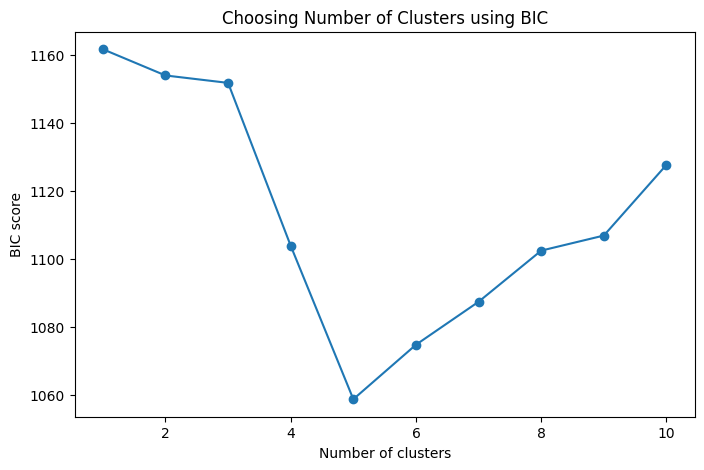

In [4]:
# 2. Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

# 3. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Try different number of clusters using BIC
bic_scores = []

for k in range(1, 11):
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(X_scaled)
    bic_scores.append(gmm.bic(X_scaled))

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), bic_scores, marker="o")
plt.xlabel("Number of clusters")
plt.ylabel("BIC score")
plt.title("Choosing Number of Clusters using BIC")
plt.show()


<h1>Bayesian Information Criterion (BIC)</h1>

<p>
BIC (Bayesian Information Criterion) is a statistical metric used to
determine the optimal number of clusters in a Gaussian Mixture Model (GMM).
</p>

<p>
One of the most important questions when using GMM is:
</p>

<blockquote>
How many clusters should the model use?
</blockquote>

<pre>
n_components = 2
n_components = 5
n_components = 10
</pre>

<p>
BIC helps answer this question automatically.
</p>

<hr>

<h2>The Problem</h2>

<p>
If we only maximize likelihood, the model will always prefer more clusters.
</p>

<pre>
1 cluster   -> decent fit
5 clusters  -> better fit
20 clusters -> even better fit
200 clusters -> nearly perfect fit
</pre>

<p>
Eventually the model begins memorizing the data instead of learning
general patterns. This is called <strong>overfitting</strong>.
</p>

<hr>

<h2>BIC Formula</h2>

<p>
The Bayesian Information Criterion is defined as:
</p>

<p style="font-size:18px;">
BIC = -2 log(L) + k log(n)
</p>

<ul>
    <li><strong>L</strong> = likelihood of the model</li>
    <li><strong>k</strong> = number of parameters</li>
    <li><strong>n</strong> = number of observations</li>
</ul>

<p>
The first term rewards models that fit the data well.
The second term penalizes models that are too complex.
</p>

<hr>

<h2>Intuition</h2>

<p>
BIC asks the following question:
</p>

<blockquote>
Does adding another cluster improve the model enough to justify the extra complexity?
</blockquote>

<hr>

<h2>Example</h2>

<table border="1" cellpadding="8">
    <tr>
        <th>Clusters</th>
        <th>Likelihood Quality</th>
        <th>BIC Score</th>
    </tr>
    <tr>
        <td>1</td>
        <td>Poor</td>
        <td>1200</td>
    </tr>
    <tr>
        <td>2</td>
        <td>Better</td>
        <td>950</td>
    </tr>
    <tr>
        <td>3</td>
        <td>Good</td>
        <td>820</td>
    </tr>
    <tr>
        <td>4</td>
        <td>Slightly Better</td>
        <td>815</td>
    </tr>
    <tr>
        <td>5</td>
        <td>Tiny Improvement</td>
        <td>830</td>
    </tr>
</table>

<p>
The best model is:
</p>

<pre>
4 clusters
</pre>

<p>
because the BIC score is the lowest.
</p>

<hr>

<h2>Important Rule</h2>

<p>
For BIC:
</p>

<pre>
Lower = Better
</pre>

<p>
The optimal number of clusters is the one with the smallest BIC score.
</p>

<hr>

<h2>Using BIC in Python</h2>

<pre>
bic_scores = []

for k in range(1, 11):

    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )

    gmm.fit(X_scaled)

    bic_scores.append(
        gmm.bic(X_scaled)
    )
</pre>

<p>
This code trains ten different GMM models:
</p>

<pre>
1 cluster
2 clusters
3 clusters
...
10 clusters
</pre>

<p>
and calculates a BIC score for each model.
</p>

<hr>

<h2>Visualizing BIC</h2>

<pre>
plt.plot(range(1, 11), bic_scores)
</pre>

<p>
Example result:
</p>

<pre>
BIC
 ^
 |
 |\
 | \
 |  \
 |   \
 |    \__
 |       \__
 |          \_
 +-------------------->
   1 2 3 4 5 6 7
</pre>

<p>
The lowest point on the curve indicates the optimal number of clusters.
</p>

<hr>

<h2>Example BIC Results</h2>

<pre>
bic_scores = [
    1200,
    950,
    800,
    760,
    770,
    790,
    820
]
</pre>

<table border="1" cellpadding="8">
    <tr>
        <th>Clusters</th>
        <th>BIC Score</th>
    </tr>
    <tr><td>1</td><td>1200</td></tr>
    <tr><td>2</td><td>950</td></tr>
    <tr><td>3</td><td>800</td></tr>
    <tr><td>4</td><td>760</td></tr>
    <tr><td>5</td><td>770</td></tr>
    <tr><td>6</td><td>790</td></tr>
    <tr><td>7</td><td>820</td></tr>
</table>

<p>
The optimal number of clusters is:
</p>

<pre>
4 clusters
</pre>

<p>
because:
</p>

<pre>
760
</pre>

<p>
is the smallest BIC value.
</p>

<hr>

<h2>Why BIC Matters in Customer Segmentation</h2>

<p>
Without BIC, choosing the number of clusters is simply a guess:
</p>

<pre>
GaussianMixture(n_components=5)
</pre>

<p>
With BIC, the data determines the appropriate number of customer segments:
</p>

<pre>
for k in range(1, 11):
    bic = gmm.bic(X_scaled)
</pre>

<p>
This helps avoid both:
</p>

<ul>
    <li>Too few clusters (underfitting)</li>
    <li>Too many clusters (overfitting)</li>
</ul>

<hr>

<h2>Practical Takeaway</h2>

<p>
When using Gaussian Mixture Models:
</p>

<ol>
    <li>Train several GMMs with different numbers of clusters.</li>
    <li>Compute the BIC score for each model.</li>
    <li>Select the model with the lowest BIC score.</li>
    <li>Interpret the resulting customer segments.</li>
</ol>

<p>
BIC balances:
</p>

<ul>
    <li>Model accuracy (likelihood)</li>
    <li>Model simplicity (number of parameters)</li>
</ul>

<p>
This is why BIC is one of the most common methods for selecting the
optimal number of clusters in a Gaussian Mixture Model.
</p>

In [5]:
# 5. Train final GMM
gmm = GaussianMixture(
    n_components=5,
    covariance_type="full",
    random_state=42
)

gmm.fit(X_scaled)

# 6. Predict cluster labels
df["Cluster"] = gmm.predict(X_scaled)

# 7. Predict probabilities
probs = gmm.predict_proba(X_scaled)

df["Confidence"] = probs.max(axis=1)


In [13]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Confidence
0,1,Male,19,15,39,4,0.999032
1,2,Male,21,15,81,2,0.999790
2,3,Female,20,16,6,4,0.999814
3,4,Female,23,16,77,2,0.999694
4,5,Female,31,17,40,4,0.998378


In [14]:
# Weight = estimated percentage of customers belonging to that segment.
# Cluster 3 weight = 0.31 - Approximately 31% of all customers belong to Cluster 3.
print("Weights:")
print(gmm.weights_)

print("Means in scaled form:")
print(gmm.means_)

# Convert means back to original units
original_means = scaler.inverse_transform(gmm.means_)

means_df = pd.DataFrame(
    original_means,
    columns=["Annual Income (k$)", "Spending Score (1-100)"]
)

means_df["Weight"] = gmm.weights_

means_df.head()

Weights:
[0.41333269 0.19669495 0.1035382  0.16552963 0.12090453]
Means in scaled form:
[[-0.18510822 -0.030786  ]
 [ 0.98021511  1.23531662]
 [-1.35282052  1.16185843]
 [ 1.07840119 -1.3228595 ]
 [-1.27977698 -1.0882964 ]]


,Annual Income (k$),Spending Score (1-100),Weight
0,55.710354,49.406987,0.413333
1,86.240633,82.020375,0.196695
2,25.117486,80.128174,0.103538
3,88.813008,16.124618,0.165530
4,27.031152,22.166702,0.120905


<h3>Visualize customer segments</h3>

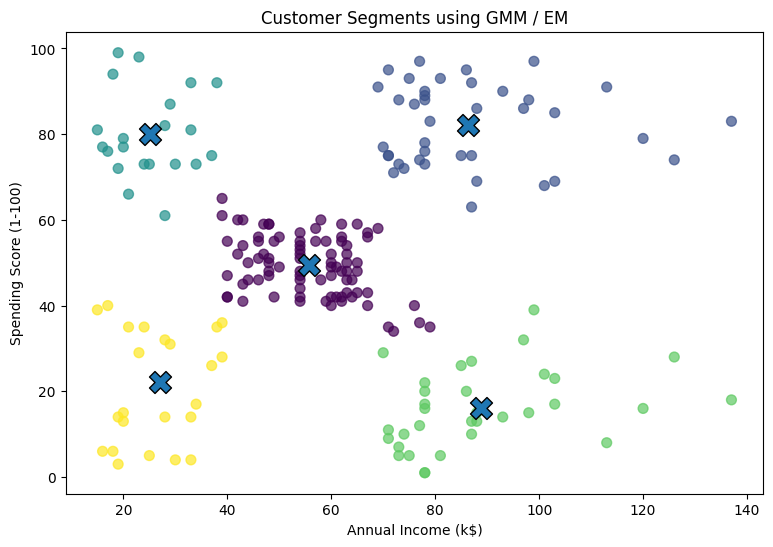

In [9]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=50,
    alpha=0.7
)

plt.scatter(
    means_df["Annual Income (k$)"],
    means_df["Spending Score (1-100)"],
    marker="X",
    s=250,
    edgecolors="black"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Segments using GMM / EM")
plt.show()

<h1>Customer Segmentation Using EM / Gaussian Mixture Models</h1>

<p>
This clustering result reveals five distinct customer segments based on
Annual Income and Spending Score.
</p>

<hr>

<h2>Segment 1 - Low Income, High Spending</h2>

<ul>
    <li><strong>Income:</strong> ~27k</li>
    <li><strong>Spending Score:</strong> ~80</li>
</ul>

<h3>Profile</h3>

<p>
Customers with relatively low income who spend heavily at the mall.
</p>

<h3>Business Interpretation</h3>

<p>
These customers may be younger shoppers, trend-focused consumers,
or highly engaged customers who prioritize shopping despite lower income.
</p>

<h3>Possible Actions</h3>

<ul>
    <li>Loyalty programs</li>
    <li>Student discounts</li>
    <li>Rewards programs</li>
    <li>Referral campaigns</li>
</ul>

<hr>

<h2>Segment 2 - Low Income, Low Spending</h2>

<ul>
    <li><strong>Income:</strong> ~27k</li>
    <li><strong>Spending Score:</strong> ~22</li>
</ul>

<h3>Profile</h3>

<p>
Budget-conscious customers who spend conservatively.
</p>

<h3>Business Interpretation</h3>

<p>
This segment is highly price-sensitive and less likely to respond to
premium offers.
</p>

<h3>Possible Actions</h3>

<ul>
    <li>Discount campaigns</li>
    <li>Coupons</li>
    <li>Seasonal sales</li>
    <li>Clearance promotions</li>
</ul>

<hr>

<h2>Segment 3 - Medium Income, Medium Spending</h2>

<ul>
    <li><strong>Income:</strong> ~55k</li>
    <li><strong>Spending Score:</strong> ~50</li>
</ul>

<h3>Profile</h3>

<p>
Average customers with average purchasing behavior.
</p>

<h3>Business Interpretation</h3>

<p>
This appears to be the largest customer segment and likely contributes
a significant portion of total revenue.
</p>

<h3>Possible Actions</h3>

<ul>
    <li>General marketing campaigns</li>
    <li>Seasonal promotions</li>
    <li>Cross-selling</li>
    <li>Product recommendations</li>
</ul>

<hr>

<h2>Segment 4 - High Income, High Spending (VIP Customers)</h2>

<ul>
    <li><strong>Income:</strong> ~86k</li>
    <li><strong>Spending Score:</strong> ~82</li>
</ul>

<h3>Profile</h3>

<p>
High-income customers who actively spend at the mall.
</p>

<h3>Business Interpretation</h3>

<p>
These customers are often the most valuable segment and can generate
significant profit.
</p>

<h3>Possible Actions</h3>

<ul>
    <li>VIP memberships</li>
    <li>Exclusive offers</li>
    <li>Early access to products</li>
    <li>Premium customer support</li>
</ul>

<hr>

<h2>Segment 5 - High Income, Low Spending</h2>

<ul>
    <li><strong>Income:</strong> ~88k</li>
    <li><strong>Spending Score:</strong> ~16</li>
</ul>

<h3>Profile</h3>

<p>
Customers with high purchasing power who are not spending much at the mall.
</p>

<h3>Business Interpretation</h3>

<p>
This is often the most interesting segment because these customers have
money available but are not purchasing. Understanding why may unlock
significant additional revenue.
</p>

<h3>Possible Actions</h3>

<ul>
    <li>Personalized marketing campaigns</li>
    <li>Premium product recommendations</li>
    <li>Customer surveys</li>
    <li>Targeted retention programs</li>
</ul>

<hr>

<h2>Key Business Insight</h2>

<p>
The clustering reveals two customer groups with similar income levels but
dramatically different spending behavior:
</p>

<ul>
    <li>High Income + High Spending</li>
    <li>High Income + Low Spending</li>
</ul>

<p>
This indicates that income alone does not explain customer spending.
Behavioral factors, customer preferences, engagement, and marketing
effectiveness likely play important roles.
</p>

<h2>Understanding GMM Outputs</h2>

<h3>Cluster Means</h3>

<p>
The large X markers on the graph represent the Gaussian means
(cluster centers).
</p>

<p>
Example:
</p>

<pre>
Income = 86k
Spending Score = 82
</pre>

<p>
This represents a typical customer within that segment.
</p>

<h3>Cluster Weights</h3>

<p>
Each cluster has a weight:
</p>

<pre>
gmm.weights_
</pre>

<p>
The weight represents the estimated proportion of customers belonging to
that segment.
</p>

<p>
Example:
</p>

<pre>
[0.12, 0.18, 0.45, 0.15, 0.10]
</pre>

<p>
Interpretation:
</p>

<ul>
    <li>Cluster 1 → 12% of customers</li>
    <li>Cluster 2 → 18% of customers</li>
    <li>Cluster 3 → 45% of customers</li>
    <li>Cluster 4 → 15% of customers</li>
    <li>Cluster 5 → 10% of customers</li>
</ul>

<p>
The weights help estimate the size and importance of each customer segment.
</p>

<h3>Predict a new customer</h3>

In [10]:
new_customers = pd.DataFrame({
    "Annual Income (k$)": [25, 80, 90, 45],
    "Spending Score (1-100)": [80, 20, 90, 50]
})

new_scaled = scaler.transform(new_customers)

new_clusters = gmm.predict(new_scaled)
new_probs = gmm.predict_proba(new_scaled)

new_customers["Predicted Cluster"] = new_clusters
new_customers["Confidence"] = new_probs.max(axis=1)

print(new_customers)
print(new_probs)

   Annual Income (k$)  Spending Score (1-100)  Predicted Cluster  Confidence
0                  25                      80                  2    0.999082
1                  80                      20                  3    0.999109
2                  90                      90                  1    1.000000
3                  45                      50                  0    0.989970
[[1.07516468e-04 7.81135803e-04 9.99081698e-01 4.11498533e-21
  2.96502143e-05]
 [8.90599503e-04 4.25732115e-10 5.56334901e-21 9.99109400e-01
  1.68978697e-10]
 [2.34435514e-16 1.00000000e+00 5.07594861e-19 1.56175736e-16
  2.37368452e-15]
 [9.89970368e-01 3.86684793e-05 1.05512228e-04 5.68399917e-08
  9.88539420e-03]]


<h3>Visualize new predictions</h3>

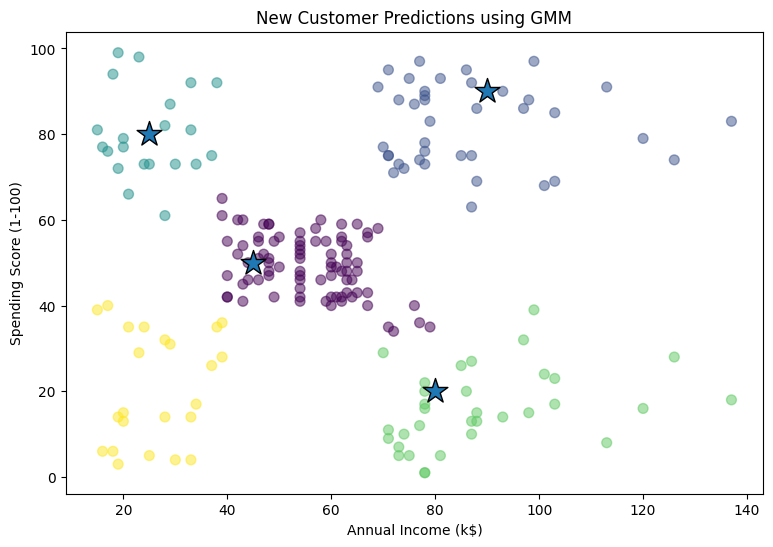

In [11]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["Cluster"],
    s=50,
    alpha=0.5
)

plt.scatter(
    new_customers["Annual Income (k$)"],
    new_customers["Spending Score (1-100)"],
    marker="*",
    s=350,
    edgecolors="black"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("New Customer Predictions using GMM")
plt.show()